In [28]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import time
import os
import csv
import re

In [29]:
# [0.0179, 0.0318, 0.0566, 0.1006, 0.1789, 0.3181, 0.5657, 1.006]
amplitudes =  [0.0318, 0.0566, 0.1006, 0.1789, 0.3181, 0.5657, 1.006]
pll_bws = [400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1500, 2000, 4000]
frequencies = [10, 50, 100, 500, 600, 700, 800, 900, 1000, 1200, 1400, 1600, 1800, 2000, 2500, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 12000, 14000, 16000, 18000, 20000]
timeout = 35  # seconds


In [30]:
(len(amplitudes) * len(pll_bws) * len(frequencies))/2/60  # hours worst case scenario

19.6

In [31]:
def wait_for_lock(freq, pll_bw):
    # Start PLL
    pll_process = subprocess.Popen(
        ['python3', '-m', 'pll', '--bw', str(pll_bw), '--sample_rate', '192000'],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        bufsize=1
    )
    
    consecutive_locks = 0
    start_time = time.time()
    tick_count = 0
    
    lock_threshold = max(5, min(100.0, 0.02 * freq))
    
    try:
        if pll_process.stdout is None:
            return '>30'

        for line in pll_process.stdout:
            elapsed = time.time() - start_time
            if elapsed > timeout:
                return '>30'
                
            line = line.strip()
            if "Initialized" in line or "Received" in line:
                continue
            
            # Parse f_est
            # Example: [229376 sps] f_est (avg):   -65.64 Hz | p_lock (avg): 0.001 | error (avg): -0.004 rad
            match = re.search(r'f_est \(avg\):\s*([-\d.]+)\s*Hz', line)
            
            if match:
                tick_count += 1
                val = match.group(1)
                print(val, end = "")
                f_est = float(val)
                if abs(abs(f_est) - freq) < lock_threshold:
                    print('!!', end = " ")
                    consecutive_locks += 1
                else:
                    print('  ', end = "")
                    consecutive_locks = 0
                    
                if consecutive_locks >= 5:
                    # Locked
                    return tick_count - 5
            
    finally:
        pll_process.terminate()
        pll_process.wait()
        print()
    return '>30'

In [32]:
def run_grid_search():
    print("Starting signal generator...")
    sig_gen = subprocess.Popen(
        ['./pll/signal_generator/signal_generator'],
        stdin=subprocess.PIPE,
        text=True,
        bufsize=1
    )
    
    print("waiting")
    time.sleep(1)
    
    for amp in amplitudes:
        print(f"Testing amplitude {amp}")
        filename = f"grid_search_amp_{amp}.csv"
        
        results = {freq: {} for freq in frequencies}
        
        for bw in pll_bws:
            consecutive_fails = 0
            for freq in frequencies:
                if consecutive_fails >= 3:
                    results[freq][bw] = '>30'
                    continue
                    
                sig_gen.stdin.write(f"a {amp}\n")
                sig_gen.stdin.write(f"f {freq}\n")
                sig_gen.stdin.flush()
                time.sleep(0.5)
                
                print(f"Amp: {amp}, BW: {bw}, Freq: {freq} - Starting test")
                lock_time = wait_for_lock(freq, bw)
                print(f"Result: {lock_time}")
                results[freq][bw] = lock_time
                
                if lock_time == '>30':
                    consecutive_fails += 1
                else:
                    consecutive_fails = 0
        
        with open(filename, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['Frequency (Hz)'] + [f'BW={bw}' for bw in pll_bws])            
            for freq in frequencies:
                row = [freq]
                for bw in pll_bws:
                    row.append(results[freq][bw])
                writer.writerow(row)

    sig_gen.terminate()
    sig_gen.wait()
    print("Done")

In [33]:
#run_grid_search()

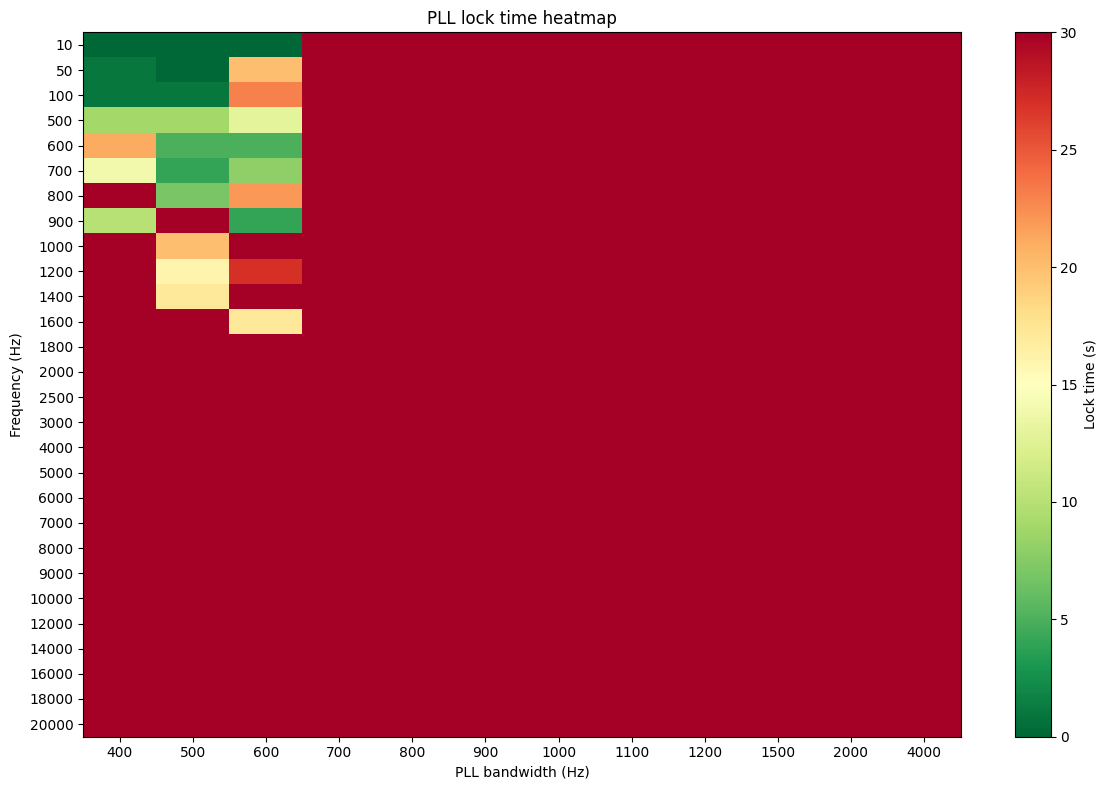

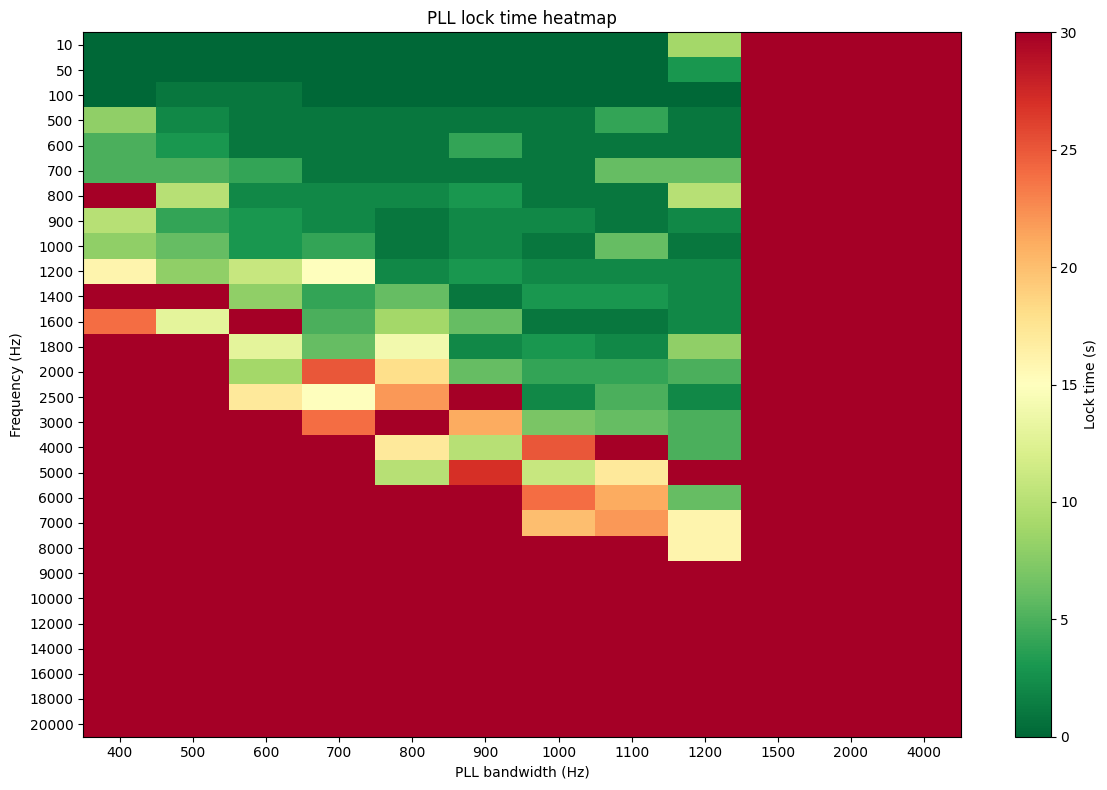

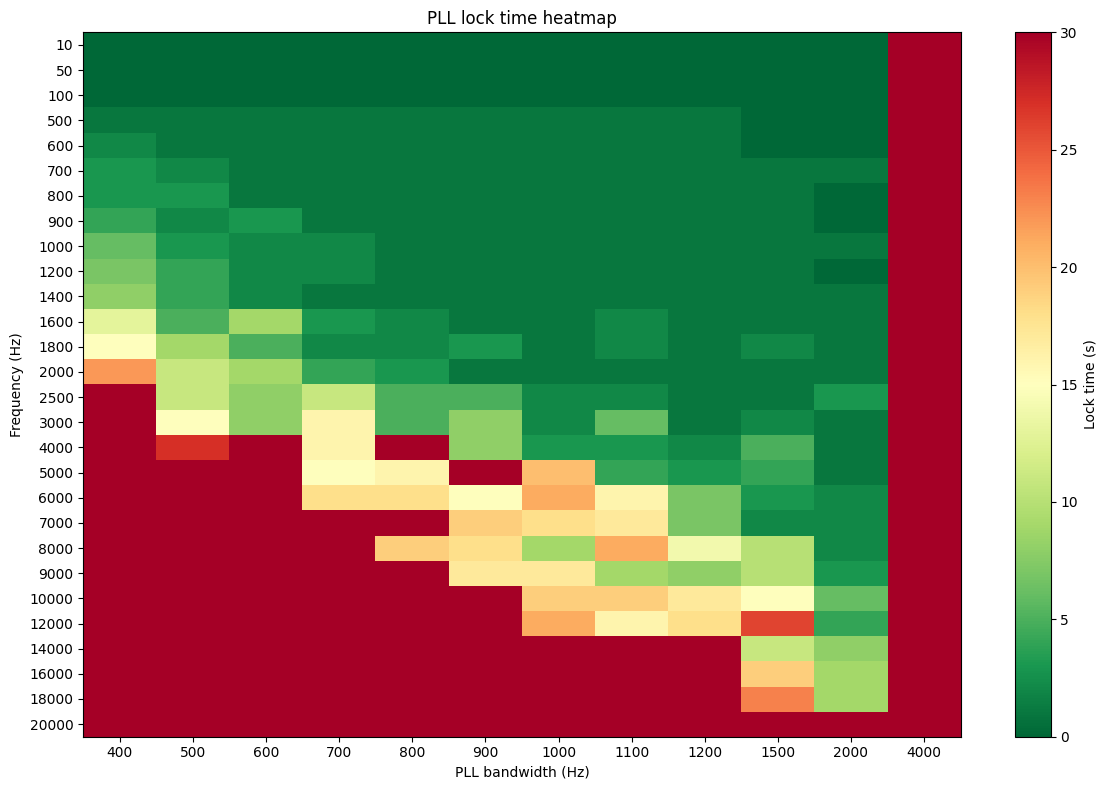

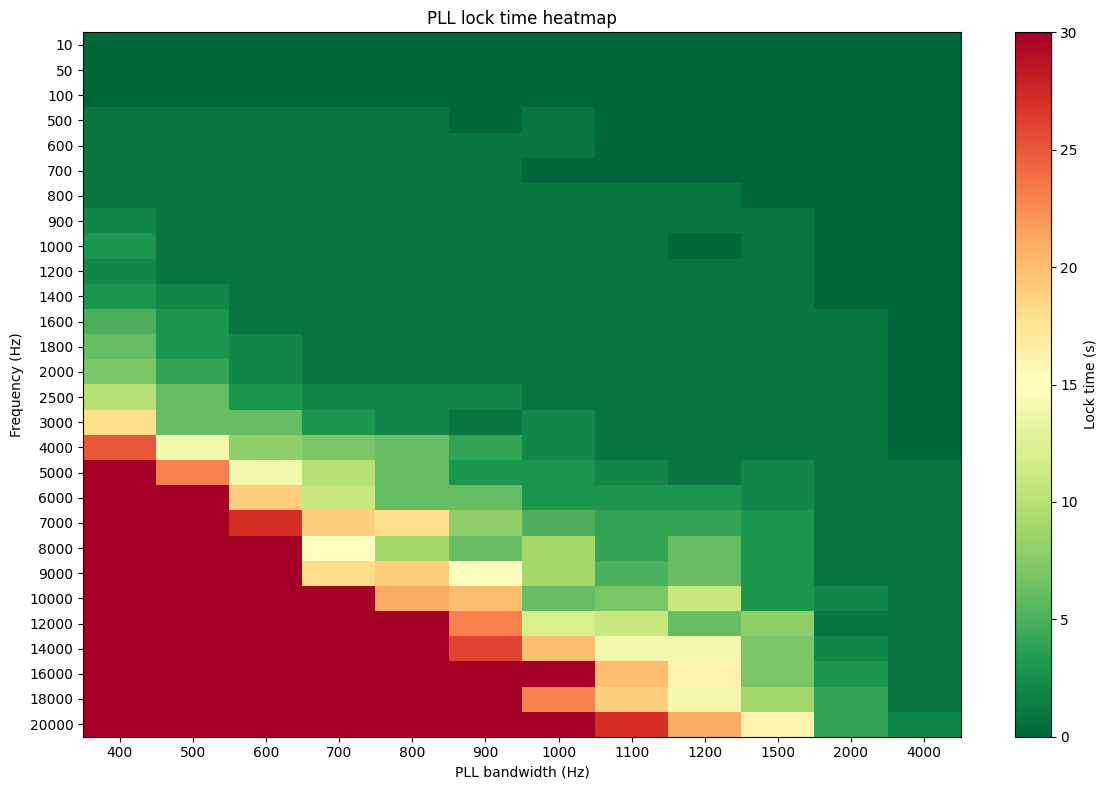

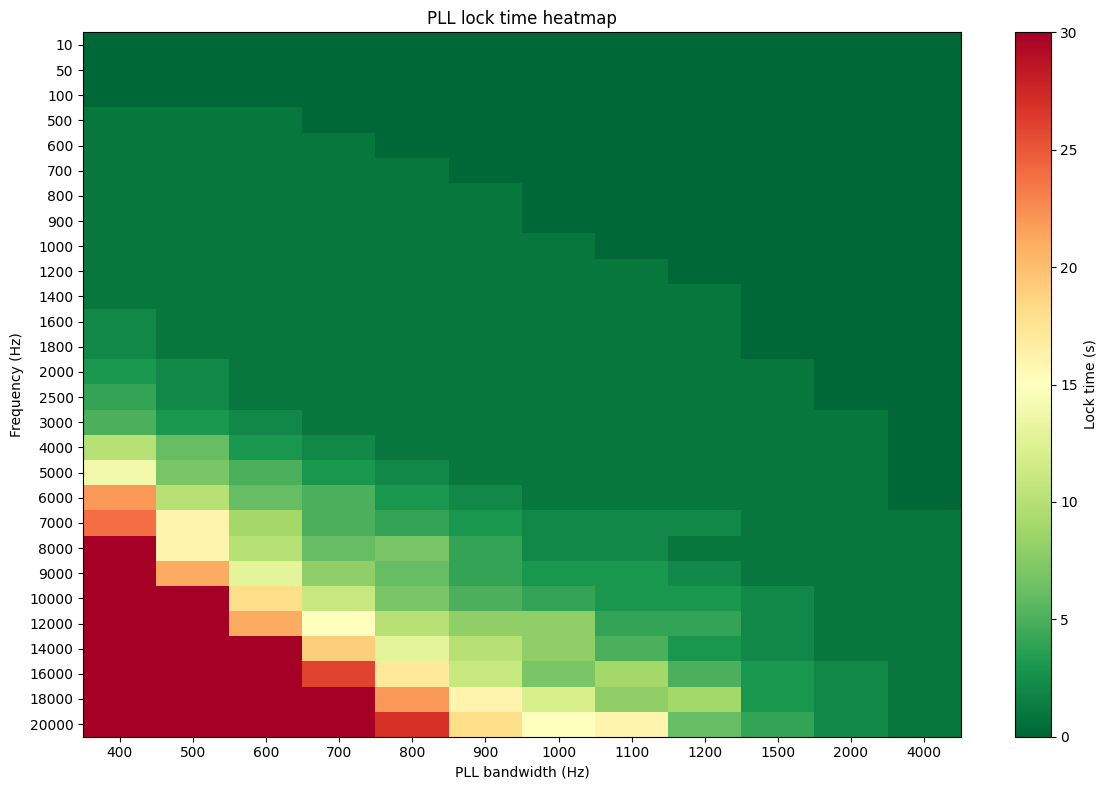

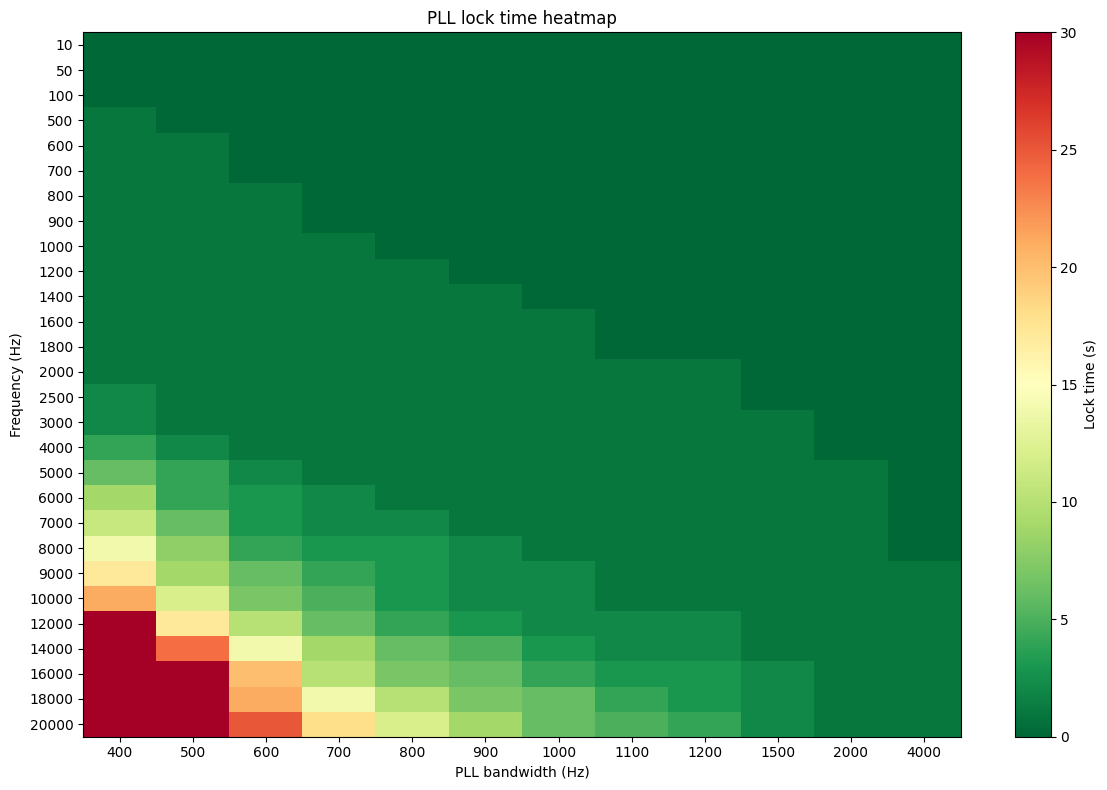

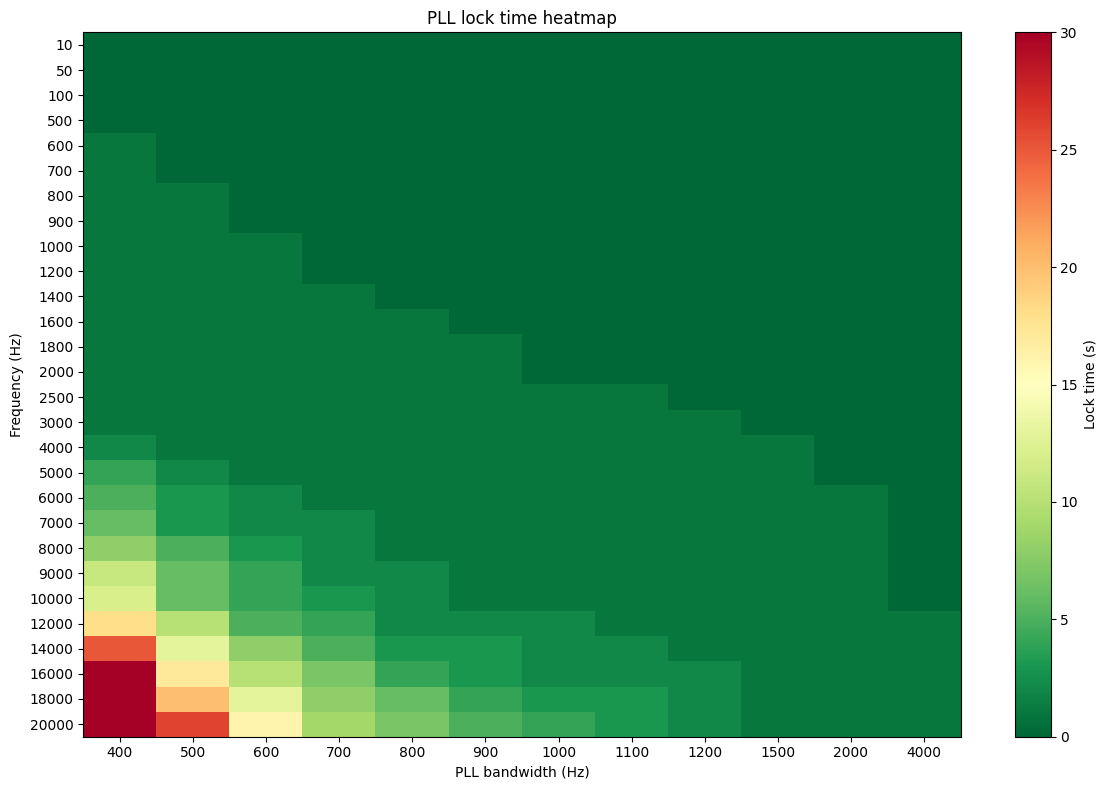

In [34]:
file_names = ["grid_search_amp_0.0318.csv", "grid_search_amp_0.0566.csv", "grid_search_amp_0.1006.csv", "grid_search_amp_0.1789.csv", "grid_search_amp_0.3181.csv", "grid_search_amp_0.5657.csv", "grid_search_amp_1.006.csv"]

for filename in file_names:
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        header = next(reader)
        data = {row[0]: row[1:] for row in reader}
        times_by_freq = []
        for freq in frequencies:
            vals = data[str(freq)]
            times = [30 if v == '>30' else float(v) for v in vals]
            times_by_freq.append(times)

        fig, ax = plt.subplots(figsize=(12, 8))
        im = ax.imshow(
            times_by_freq,
            aspect='auto',
            cmap='RdYlGn_r',   # green = low, red = high
            vmin=0,
            vmax=30
        )

        ax.set_xticks(np.arange(len(pll_bws)))
        ax.set_xticklabels(pll_bws)
        ax.set_yticks(np.arange(len(frequencies)))
        ax.set_yticklabels(frequencies)

        ax.set_xlabel("PLL bandwidth (Hz)")
        ax.set_ylabel("Frequency (Hz)")
        ax.set_title("PLL lock time heatmap")

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Lock time (s)")

        plt.tight_layout()
        plt.show()

    

In [35]:
speeds = [50, 100, 200, 400, 800, 1200, 2000, 4000] # Hz/sec
speed_check_duration = 10 # seconds

def measure_rmse_for_speed(sig_gen, amp, bw, spd):
    sig_gen.stdin.write(f"a {amp}\n")
    sig_gen.stdin.write("f 0\n")
    sig_gen.stdin.flush()
    time.sleep(0.5)
    
    pll_process = subprocess.Popen(
        ['python3', '-m', 'pll', '--bw', str(bw), '--sample_rate', '192000'],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        bufsize=1
    )
    
    started = False
    total_samples = 0
    errors_sq = []
    
    try:
        if pll_process.stdout is None:
            return float('inf')
        
        for line in pll_process.stdout:
            line = line.strip()
            # Capture the number of samples in the block to track exact signal timing
            match = re.search(r'\[(\d+)\s*sps\].*?f_est \(avg\):\s*([-\d.]+)\s*Hz', line)
            if match:
                sps = int(match.group(1))
                f_est = float(match.group(2))
                
                if not started:
                    # Sync start of tracking with linear sweep trigger
                    sig_gen.stdin.write(f"linear {spd}\n")
                    sig_gen.stdin.flush()
                    started = True
                    total_samples = 0
                    continue
                    
                total_samples += sps
                block_duration = sps / 192000.0
                signal_time = total_samples / 192000.0
                
                if signal_time > speed_check_duration:
                    break
                    
                # Apply the center of mass alignment fix: 
                # The average reported by the PLL is at the midpoint of the sample block.
                midpoint_time = signal_time - (block_duration / 2.0)
                f_ideal = -spd * midpoint_time
                
                print(f"[{f_est:.1f} vs {f_ideal:.1f}]", end=" ")
                errors_sq.append((f_est - f_ideal)**2)
        print()
    finally:
        pll_process.terminate()
        pll_process.wait()
        sig_gen.stdin.write("stop\n")
        sig_gen.stdin.flush()
        time.sleep(0.1)
        
    if not errors_sq:
        return float('inf')
        
    return np.sqrt(np.mean(errors_sq))

def run_speed_grid_search():
    print("Starting signal generator for speed grid search...")
    sig_gen = subprocess.Popen(
        ['./pll/signal_generator/signal_generator'],
        stdin=subprocess.PIPE,
        text=True,
        bufsize=1
    )
    time.sleep(1)
    
    try:
        for bw in pll_bws:
            print(f"Testing PLL BW {bw}")
            filename = f"grid_search_spd_{bw}.csv"
            results = {spd: {} for spd in speeds}
            
            for amp in amplitudes:
                for spd in speeds:
                    print(f"BW: {bw}, Amp: {amp}, Speed: {spd} - Starting test")
                    rmse = measure_rmse_for_speed(sig_gen, amp, bw, spd)
                    print(f"\nResult RMSE: {rmse:.4f}")
                    results[spd][amp] = rmse
            
            with open(filename, 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(['Speed (Hz/s)'] + [f'Amp={amp}' for amp in amplitudes])            
                for spd in speeds:
                    row = [spd]
                    for amp in amplitudes:
                        row.append(results[spd][amp])
                    writer.writerow(row)
    finally:
        sig_gen.terminate()
        sig_gen.wait()
        print("Speed grid search done")

In [36]:
#run_speed_grid_search()

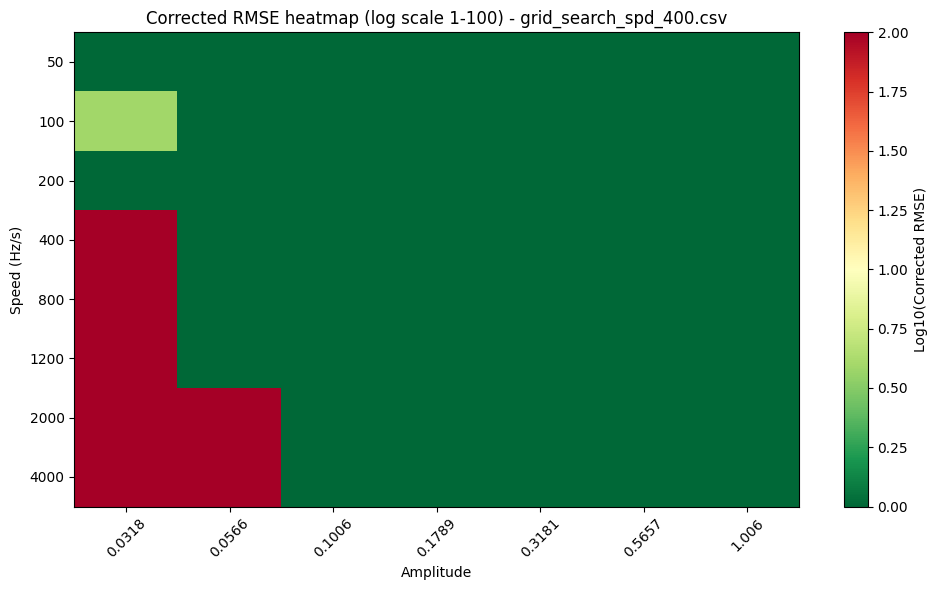

Exception ignored while finalizing file <_io.TextIOWrapper name=90 encoding='UTF-8'>:
Traceback (most recent call last):
  File "<frozen abc>", line 117, in __instancecheck__
BrokenPipeError: [Errno 32] Broken pipe


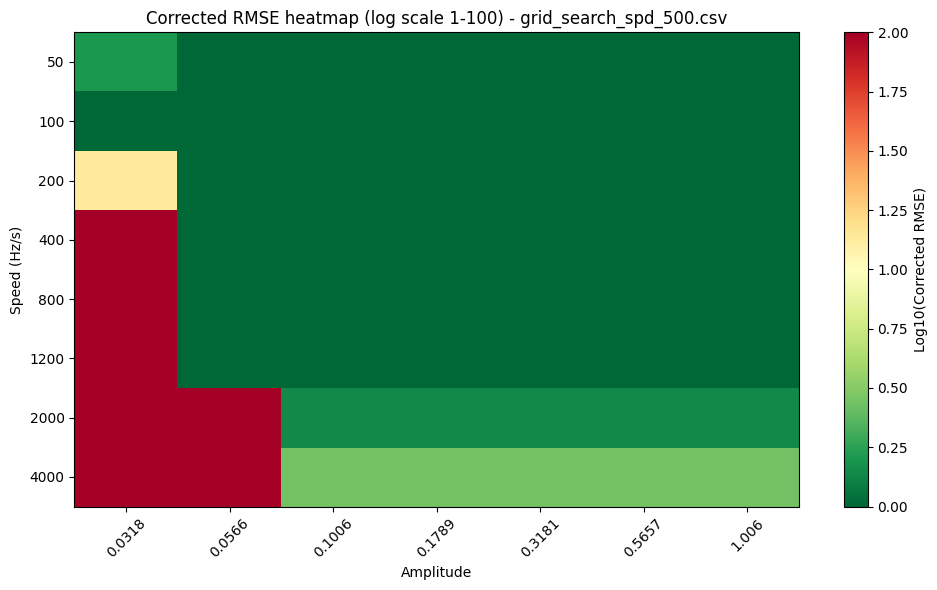

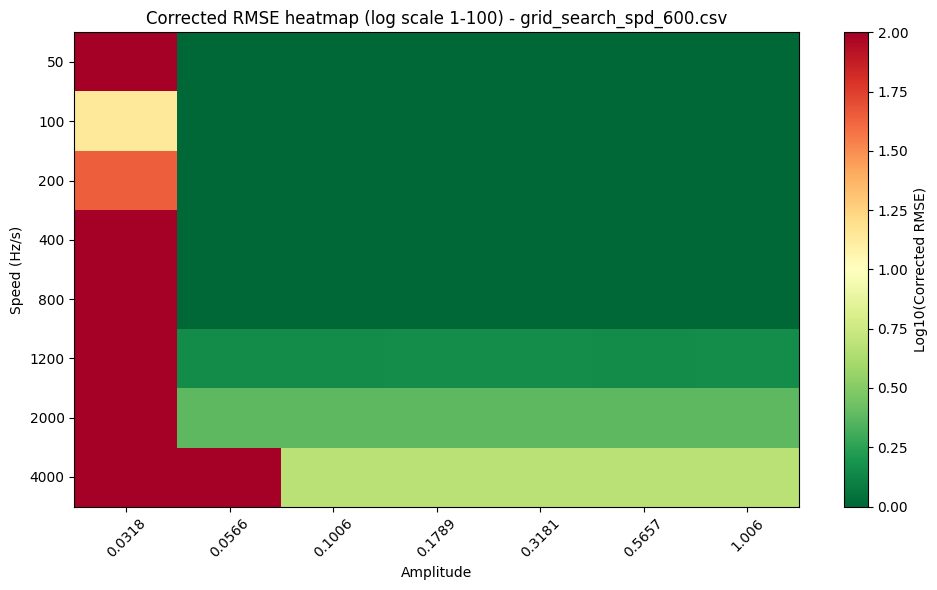

Exception ignored while finalizing file <_io.TextIOWrapper name=97 encoding='UTF-8'>:
Traceback (most recent call last):
  File "<string>", line 1, in <lambda>
BrokenPipeError: [Errno 32] Broken pipe


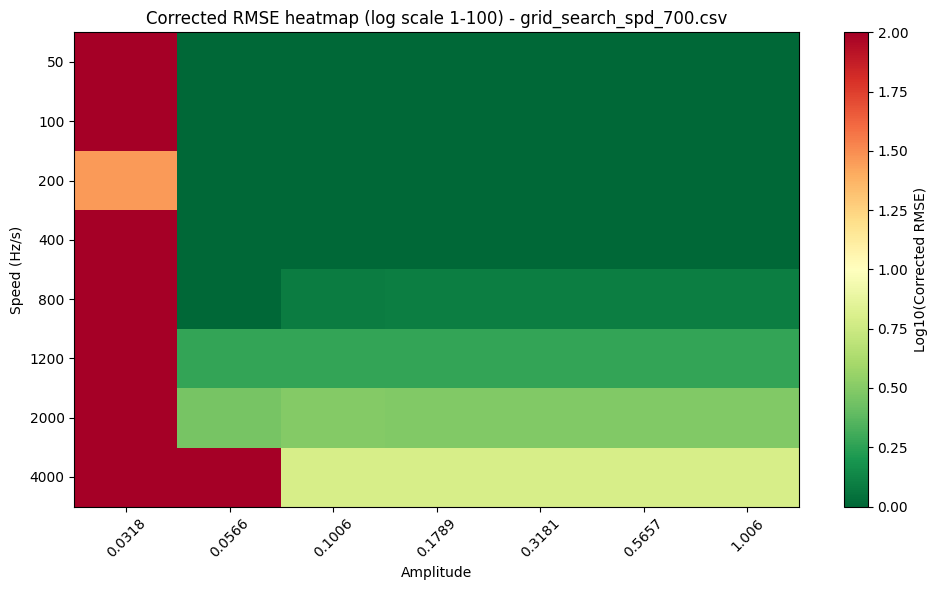

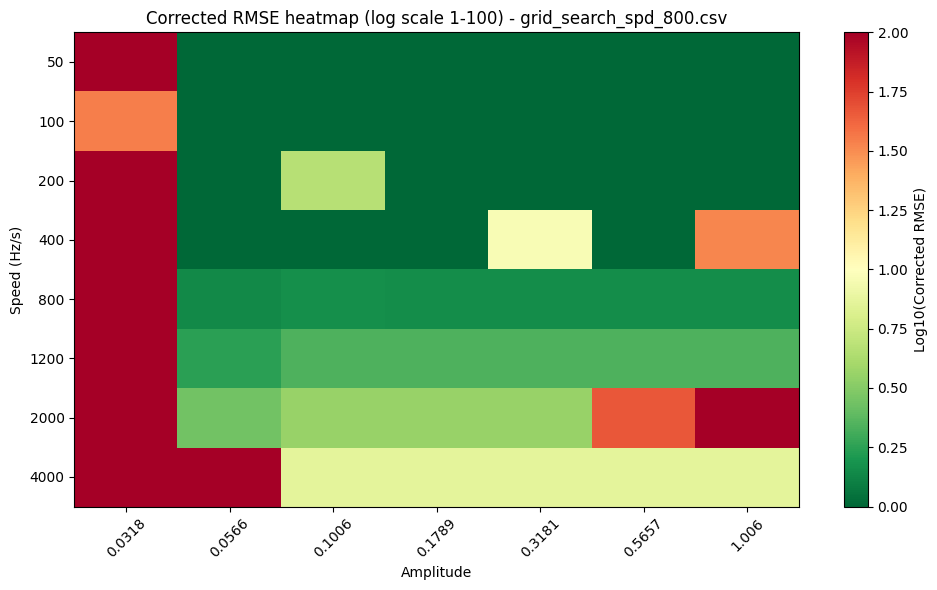

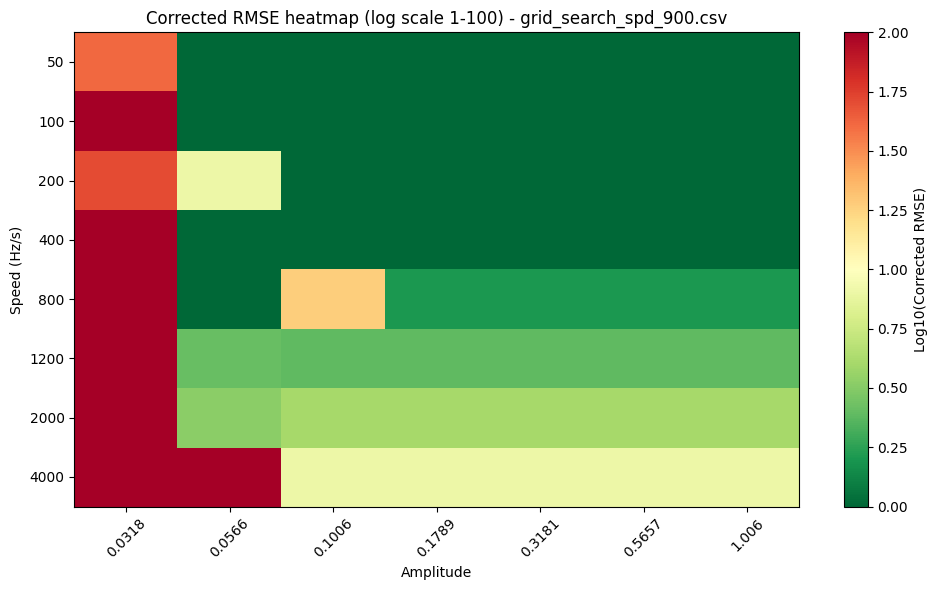

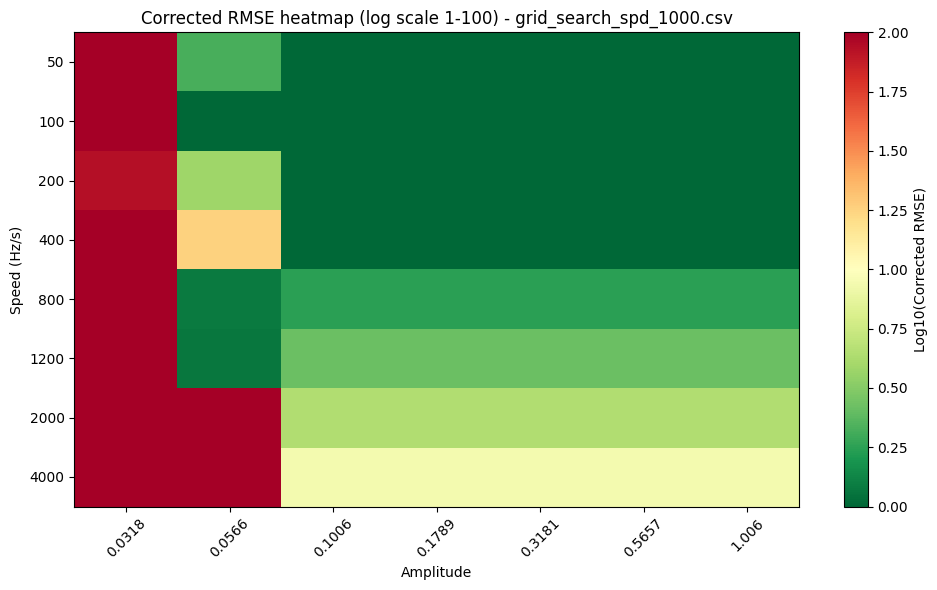

In [39]:
spd_file_names = ["grid_search_spd_400.csv", "grid_search_spd_500.csv", "grid_search_spd_600.csv", "grid_search_spd_700.csv", "grid_search_spd_800.csv", "grid_search_spd_900.csv", "grid_search_spd_1000.csv"]

for filename in spd_file_names:
    with open(filename, 'r') as f:
        reader = csv.reader(f)
        header = next(reader)
        data = {row[0]: row[1:] for row in reader}
        matrix = []
        for spd in speeds:
            vals = data.get(str(spd), ['>30'] * len(amplitudes))
            row = []
            for v in vals:
                try:
                    val = float(v) if v != '>30' else 1e6
                except:
                    val = 1e6
                corrected = abs(val - (spd / 40.0))
                row.append(corrected)
            matrix.append(row)

        matrix = np.array(matrix)
        # Apply logarithmic scaling
        matrix = np.log10(np.maximum(matrix, 1))  # Ensure values >= 1 before log

        fig, ax = plt.subplots(figsize=(10, 6))
        im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=2)  # log10(1)=0, log10(100)=2

        ax.set_xticks(np.arange(len(amplitudes)))
        ax.set_xticklabels([str(a) for a in amplitudes], rotation=45)
        ax.set_yticks(np.arange(len(speeds)))
        ax.set_yticklabels(speeds)

        ax.set_xlabel("Amplitude")
        ax.set_ylabel("Speed (Hz/s)")
        ax.set_title(f"Corrected RMSE heatmap (log scale 1-100) - {filename}")

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Log10(Corrected RMSE)")

        plt.tight_layout()
        plt.show()
